In [30]:
#just a discliamee that a chat bot has put me in a direction to solbe this problem however it was there as a guidline only, some did not need chatbots help chat bot has been citated and refernced in relavent place

In [1]:
import pandas as pd
import matplotlib.pyplot as plt 
import requests
from bs4 import BeautifulSoup
import nltk
from nltk.corpus import stopwords, wordnet
from nltk.tokenize import word_tokenize
from nltk.stem import WordNetLemmatizer
from gensim import corpora, models
import re
import seaborn as sns
from collections import Counter

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report,confusion_matrix





"""
PassengerId - Passenger number
Survived - 0 = Dead 1 = Alive

Pclass - 1 = First class 2 = Second class 3 = Third class
Name - Name of passenger
Sex - Gender
Age - Age of passenger
SibSp - Number of siblings/Spouses
Parch - Number of Parents/Children Aboard - 
Ticket - Ticket
Fare - Price of ticket(In British pound)
Cabin - Location of stay for passenger.
Embarked - C = Cherbourg Q = Queenstown S = Southampton

"""

# TODO Clean dataset
# - Cabin has 78.2% of the data missing
# - Name in the correct format.
# - Restructuring age.
# - Understand Fare price (British Pounds)
# - Understand Ticket data.

df_tested = pd.read_csv("tested.csv")
missing_data = df_tested.isnull().sum()
missing_data = missing_data[missing_data > 0]

In [2]:


# print(missing_data_info)
        
    
    


df_tested['CabinKnown'] = df_tested['Cabin'].notnull().astype(int)




In [3]:
# Filling missing 'Age' values with the median age
median_age = df_tested['Age'].median()
df_tested['Age'].fillna(median_age, inplace=True)


In [4]:
# Filling missing 'Embarked' values with the mode (most common value)
mode_embarked = df_tested['Embarked'].mode()[0]
df_tested['Embarked'].fillna(mode_embarked, inplace=True)


In [5]:
# Rechecking for missing data
updated_missing_data = df_tested.isnull().sum()
updated_missing_data = updated_missing_data[updated_missing_data > 0]
updated_missing_data_percentage = (updated_missing_data / len(df_tested)) * 100

In [6]:
# Updated missing data information
updated_missing_data_info = pd.DataFrame(
    {'Remaining Missing Values': updated_missing_data, 'Percentage (%)': updated_missing_data_percentage})
updated_missing_data_info.sort_values(by='Percentage (%)', ascending=False)


,Remaining Missing Values,Percentage (%)
Cabin,327,78.229665
Fare,1,0.239234


In [7]:
# print(updated_missing_data_info)


summary_statistics = df_tested.describe(include='all')
summary_statistics.transpose()
print(summary_statistics)

        PassengerId    Survived      Pclass              Name   Sex  \
count    418.000000  418.000000  418.000000               418   418   
unique          NaN         NaN         NaN               418     2   
top             NaN         NaN         NaN  Kelly, Mr. James  male   
freq            NaN         NaN         NaN                 1   266   
mean    1100.500000    0.363636    2.265550               NaN   NaN   
std      120.810458    0.481622    0.841838               NaN   NaN   
min      892.000000    0.000000    1.000000               NaN   NaN   
25%      996.250000    0.000000    1.000000               NaN   NaN   
50%     1100.500000    0.000000    3.000000               NaN   NaN   
75%     1204.750000    1.000000    3.000000               NaN   NaN   
max     1309.000000    1.000000    3.000000               NaN   NaN   

               Age       SibSp       Parch    Ticket        Fare  \
count   418.000000  418.000000  418.000000       418  417.000000   
unique     

In [8]:
# Set the aesthetic style of the plots
sns.set(style="whitegrid")


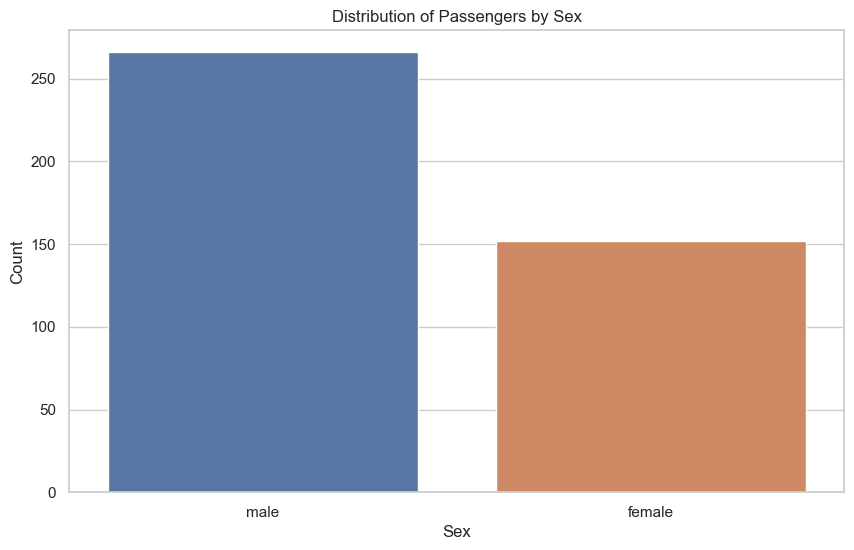

In [9]:
# Categorical: Distribution of passengers by sex
plt.figure(figsize=(10, 6))
sns.countplot(x='Sex', data=df_tested)
plt.title('Distribution of Passengers by Sex')
plt.xlabel('Sex')
plt.ylabel('Count')
plt.show()


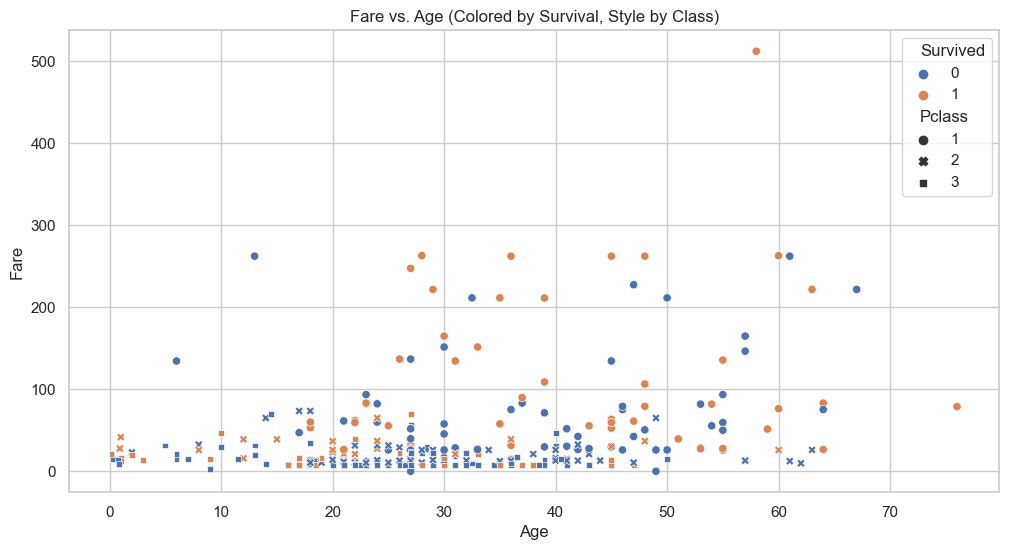

In [10]:
# Relational: Fare paid vs. Age
plt.figure(figsize=(12, 6))
sns.scatterplot(x='Age', y='Fare', hue='Survived', style='Pclass', data=df_tested)
plt.title('Fare vs. Age (Colored by Survival, Style by Class)')
plt.xlabel('Age')
plt.ylabel('Fare')
plt.show()

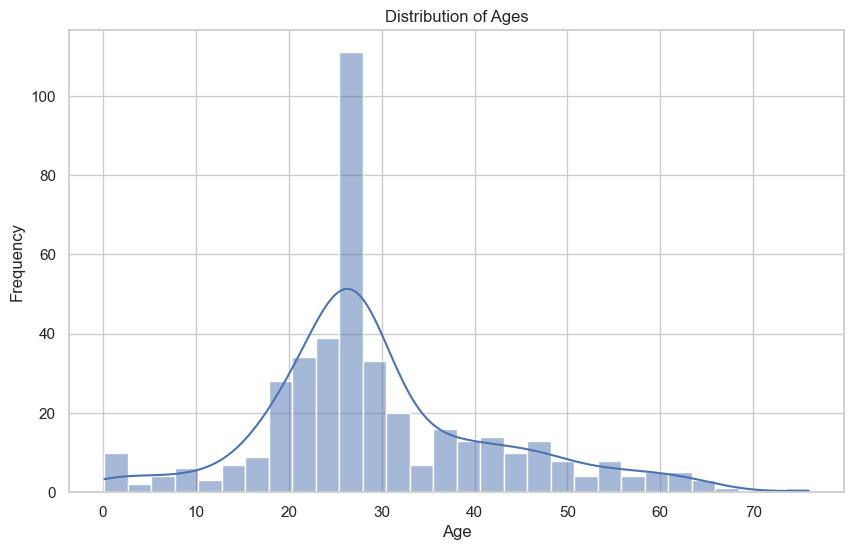

In [11]:

# Temporal: Histogram of Ages
plt.figure(figsize=(10, 6))
sns.histplot(df_tested['Age'], bins=30, kde=True)
plt.title('Distribution of Ages')
plt.xlabel('Age')
plt.ylabel('Frequency')
plt.show()

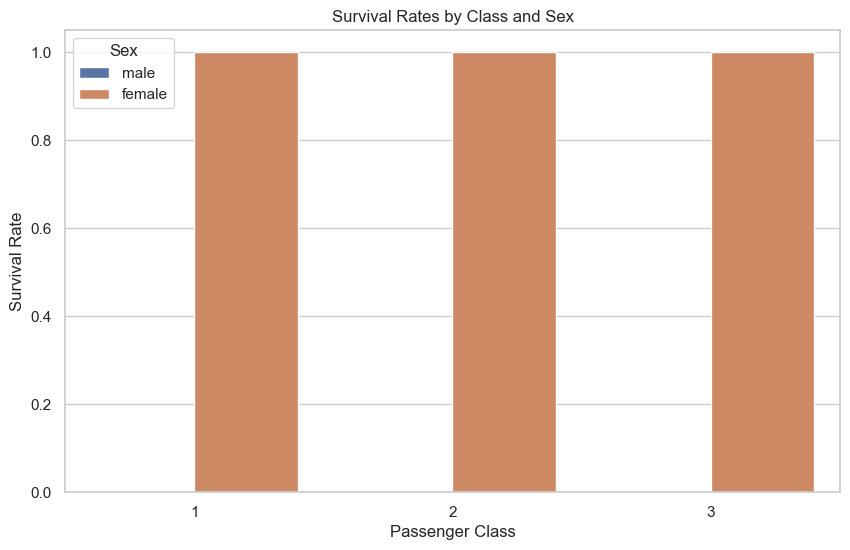

In [12]:
# Hierarchical: Survival rates by class and sex
plt.figure(figsize=(10, 6))
sns.barplot(x='Pclass', y='Survived', hue='Sex', data=df_tested)
plt.title('Survival Rates by Class and Sex')
plt.xlabel('Passenger Class')
plt.ylabel('Survival Rate')
plt.show()

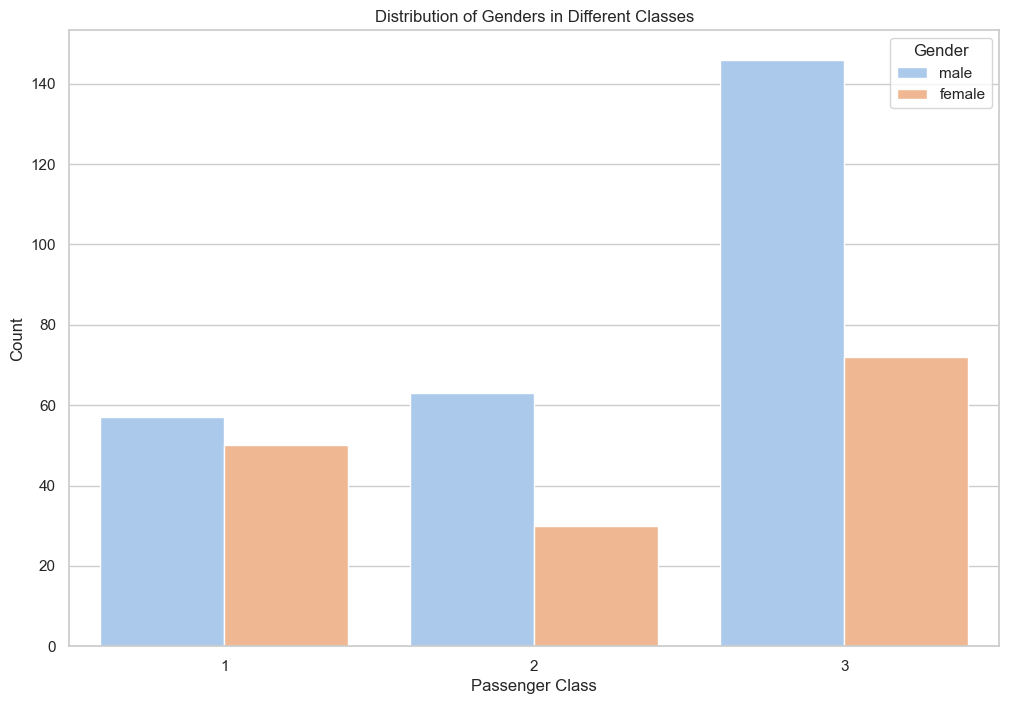

In [13]:


# Hierarchical: Different genders in different classes
plt.figure(figsize=(12, 8))
sns.countplot(x='Pclass', hue='Sex', data=df_tested, palette='pastel')
plt.title('Distribution of Genders in Different Classes')
plt.xlabel('Passenger Class')
plt.ylabel('Count')
plt.legend(title='Gender', loc='upper right')
plt.show()




In [14]:
# this code in credited OpenAI. (N/D). 
# start the prediction bit
# Convert categorical variable 'Sex' to numerical
X = df_tested[['Pclass', 'Sex']]  # Features
y = df_tested['Survived']          # Target variable

In [15]:
# Convert categorical variable 'Sex' to numerical
X = pd.get_dummies(X, columns=['Sex'], drop_first=True)

In [16]:
#Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)



In [17]:
# Build a Random Forest Classifie
clf = RandomForestClassifier(random_state=42)# This is when the train and test sets directly affect the model's performance score.
clf.fit(X_train, y_train)

RandomForestClassifier(random_state=42)

In [18]:
# this is the  Predictions bit
y_pred = clf.predict(X_test)

In [19]:
# checking out the model by evalating it
print(f'How accurate is this?  : {accuracy_score(y_test, y_pred)}')
print('\nClassification Report:\n', classification_report(y_test, y_pred))
print('\nConfusion Matrix:\n', confusion_matrix(y_test, y_pred))

How accurate is this?  : 1.0

Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00        50
           1       1.00      1.00      1.00        34

    accuracy                           1.00        84
   macro avg       1.00      1.00      1.00        84
weighted avg       1.00      1.00      1.00        84


Confusion Matrix:
 [[50  0]
 [ 0 34]]


In [20]:
# handling any missing data which is out there 
df_tested['CabinKnown'] = df_tested['Cabin'].notnull().astype(int)

In [21]:
# Filling missing 'Age' values with the ageallall gust whichin the middle age aka the medium number 
median_age = df_tested['Age'].median()
df_tested['Age'].fillna(median_age, inplace=True)

In [22]:
# filling any emabraked values which are missing (most common value)
mode_embarked = df_tested['Embarked'].mode()[0]
df_tested['Embarked'].fillna(mode_embarked, inplace=True)

In [23]:
# double checking for any missing data out there, also check twice some data could be missed if only checked one 
updated_missing_data = df_tested.isnull().sum()
updated_missing_data = updated_missing_data[updated_missing_data > 0]
updated_missing_data_percentage = (updated_missing_data / len(df_tested)) * 100

In [24]:
# missing data information being updated 
updated_missing_data_info = pd.DataFrame(
    {'Remaining Missing Values': updated_missing_data, 'Percentage (%)': updated_missing_data_percentage})
updated_missing_data_info.sort_values(by='Percentage (%)', ascending=False)


,Remaining Missing Values,Percentage (%)
Cabin,327,78.229665
Fare,1,0.239234
